Training data shape: (60000, 784)
Testing data shape: (10000, 784)
Epoch 1/10, Loss: 0.3215, Training Accuracy (sample): 64.86%
Epoch 2/10, Loss: 0.2781, Training Accuracy (sample): 71.82%
Epoch 3/10, Loss: 0.2425, Training Accuracy (sample): 76.14%
Epoch 4/10, Loss: 0.2107, Training Accuracy (sample): 78.68%
Epoch 5/10, Loss: 0.1861, Training Accuracy (sample): 80.14%
Epoch 6/10, Loss: 0.1676, Training Accuracy (sample): 82.06%
Epoch 7/10, Loss: 0.1535, Training Accuracy (sample): 83.48%
Epoch 8/10, Loss: 0.1423, Training Accuracy (sample): 84.54%
Epoch 9/10, Loss: 0.1333, Training Accuracy (sample): 85.26%
Epoch 10/10, Loss: 0.1259, Training Accuracy (sample): 85.96%

Final Test Loss: 0.1199
Test Accuracy: 86.2 %


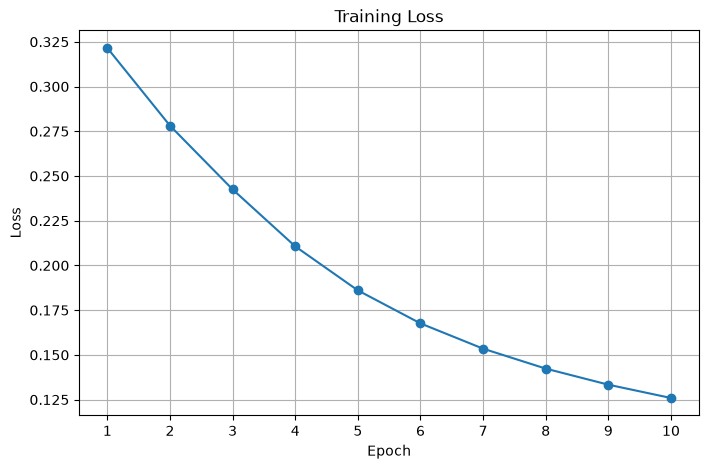

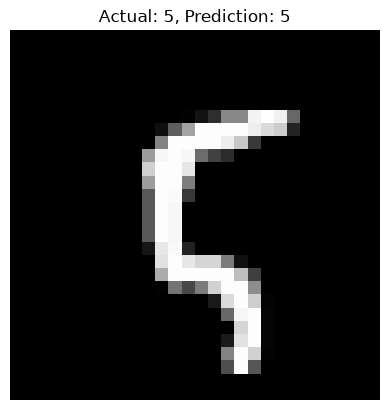

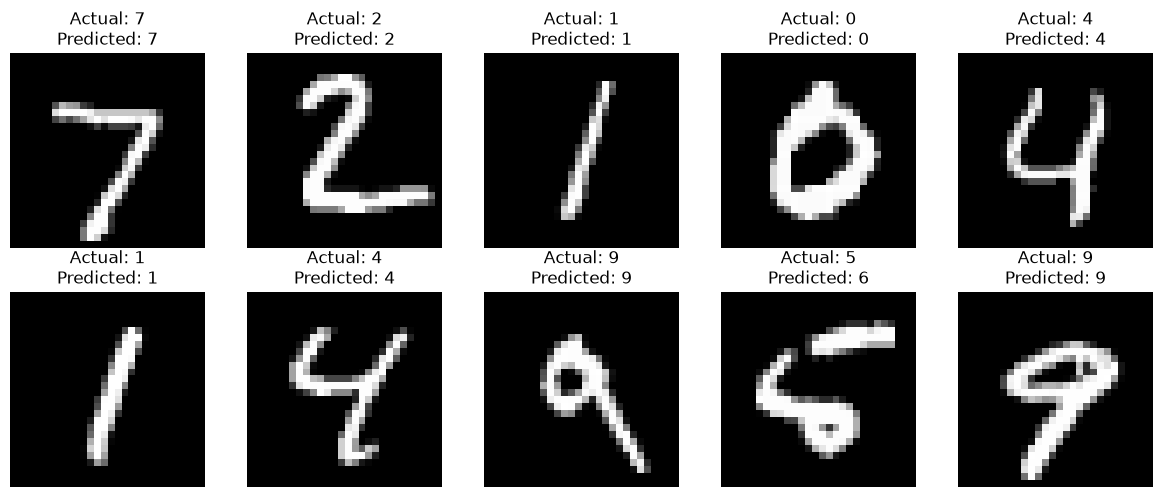

Experiment 1 Completed Successfully!


In [1]:

# EX 1: THREE-LAYER NEURAL NETWORK FROM SCRATCH
# Handwritten Digit Recognition using MNIST

# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Step 2: Load and Preprocess the Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test = X_test.reshape(-1, 784).astype(np.float32) / 255.0

# One-hot encoding
y_train = np.eye(10)[y_train]
y_test_labels = y_test.copy()
y_test = np.eye(10)[y_test]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Step 3: Initialize the Network
np.random.seed(42)

input_size = 784
hidden_size = 64
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
b2 = np.zeros((1, output_size))

# Step 4: Define Activation and Loss Functions
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

def loss_fn(y, y_hat):
    y_hat = np.clip(y_hat, 1e-8, 1 - 1e-8)
    return -np.mean(
        y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)
    )

# Step 5: Train the Model using Backpropagation
epochs = 10
lr = 0.1
batch_size = 128
losses = []

for epoch in range(epochs):
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    total_loss = 0
    num_batches = 0

    for start in range(0, X_train.shape[0], batch_size):
        x = X_shuffled[start:start + batch_size]
        y = y_shuffled[start:start + batch_size]
        m = x.shape[0]

        # Forward Propagation
        z1 = x @ W1 + b1
        a1 = sigmoid(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # Calculate Loss
        loss = loss_fn(y, a2)
        total_loss += loss
        num_batches += 1

        # Backpropagation
        dz2 = (a2 - y) / (m * output_size)
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update Weights and Biases
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    epoch_loss = total_loss / num_batches
    losses.append(epoch_loss)

    # Calculate Training Accuracy
    train_predictions = np.argmax(
        sigmoid(sigmoid(X_train[:5000] @ W1 + b1) @ W2 + b2),
        axis=1
    )
    train_accuracy = np.mean(
        train_predictions == np.argmax(y_train[:5000], axis=1)
    ) * 100

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {epoch_loss:.4f}, "
        f"Training Accuracy (sample): {train_accuracy:.2f}%"
    )

# Step 6: Evaluate the Model
z1_test = X_test @ W1 + b1
a1_test = sigmoid(z1_test)
z2_test = a1_test @ W2 + b2
a2_test = sigmoid(z2_test)

test_loss = loss_fn(y_test, a2_test)
y_pred = np.argmax(a2_test, axis=1)
test_accuracy = np.mean(y_pred == y_test_labels) * 100

print("\nFinal Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 2), "%")

# Step 7: Visualize Training Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.show()

# Step 8: Predict a Sample Digit
def predict(img):
    img = img.reshape(1, 784).astype(np.float32) / 255.0
    a1 = sigmoid(img @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)
    return np.argmax(a2)

idx = 100
sample_image = mnist.load_data()[0][0][idx]
prediction = predict(sample_image)

plt.imshow(sample_image, cmap='gray')
plt.title(f"Actual: {y_train[idx].argmax()}, Prediction: {prediction}")
plt.axis('off')
plt.show()

# Step 9: Display Multiple Predictions
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(
        f"Actual: {y_test_labels[i]}\nPredicted: {y_pred[i]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Experiment 1 Completed Successfully!")